### **Image Classification with the MNIST Dataset**

In [ ]:
x1w1=0.4+b=0.5
x1w2=0.33+b=0.9



x2w2+b=0.9


activation function:

relu  ----> -12-->0
12-relu


sigmoid-->0,,yes,no

In traditional programming, the programmer is able to articulate rules and conditions in their code that
their program can then use to act in the correct way. This approach continues to work exceptionally well
for a huge variety of problems.
Image classification, which asks a program to correctly classify an image it has never seen before into
its correct class, is near impossible to solve with traditional programming techniques. How could a
programmer possibly define the rules and conditions to correctly classify a huge variety of images,
especially taking into account images that they have never seen?

**The Solution: Deep Learning**

Deep learning excels at pattern recognition by trial and error. By training a deep neural network with
sufficient data, and providing the network with feedback on its performance via training, the network can
identify, though a huge amount of iteration, its own set of conditions by which it can act in the correct
way.

**The MNIST Dataset**

In the history of deep learning, the accurate image classification of the MNIST dataset
(http://yann.lecun.com/exdb/mnist/), a collection of 70,000 grayscale images of handwritten digits from 0
to 9, was a major development. While today the problem is considered trivial, doing image classification
with MNIST has become a kind of "Hello World" for deep learning.

We will begin by loading the Keras dataset module for MNIST

In [2]:
from tensorflow.keras.datasets import mnist



(x_train,y_train),(x_test,y_test)=mnist.load_data()
print(x_train.shape)
print(y_train.shape)


# x_train=x_train.reshape(60000,784)
# x_test=x_test.reshape(10000,784)


# x_train=x_train/255
# x_test=x_test/255




# from tensorflow.keras.utils import to_categorical

# num_categories=10
# y_train=to_categorical(y_train,num_categories)
# y_test=to_categorical(y_test,num_categories)



# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# model=Sequential()

# model.add(Dense(units=512,activation='relu',input_shape=(784,)))
# model.add(Dense(units=512,activation='relu'))
# model.add(Dense(units=10,activation='softmax'))

# model.compile(loss='categorical_crossentropy',metrics=['accuracy'])

# his=model.fit(x_train,y_train,epochs=5,verbose=1,validation_data=(x_test,y_test))








(60000, 28, 28)
(60000,)


In [ ]:
from tensorflow.keras.datasets import mnist

With the mnist module, we can easily load the MNIST data, already partitioned into images and labels
for both training and validation:

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

**Exploring the MNIST Data**

We stated above that the MNIST dataset contained 70,000 grayscale images of handwritten digits. By
executing the following cells, we can see that Keras has partitioned 60,000 of these images for training,
and 10,000 for validation (after training), and also, that each image itself is a 2D array with the
dimensions 28x28:


In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
x_test.shape

(10000, 28, 28)

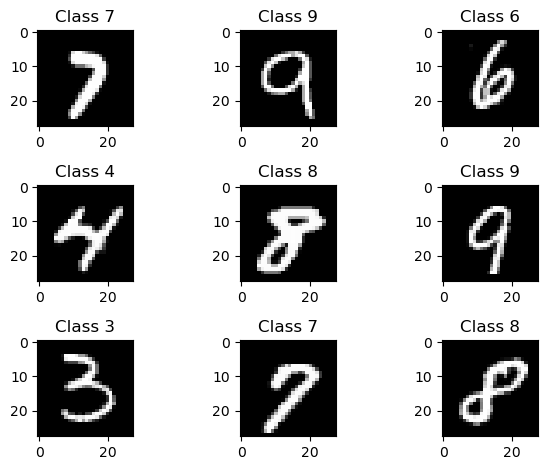

In [7]:
import random
import matplotlib.pyplot as plt

for i in range(9):
 plt.subplot(3,3,i+1)
 num = random.randint(0, len(x_train))
 plt.imshow(x_train[num], cmap='gray')
 plt.title("Class {}".format(y_train[num]))
# plt.show()
plt.tight_layout()


**Preparing the Data for Training**

In deep learning, it is common that data needs to be transformed to be in the ideal state for training. For
this particular image classification problem, there are 3 tasks we should perform with the data in
preparation for training:
1. Flatten the image data, to simplify the image input into the model
2. Normalize the image data, to make the image input values easier to work with for the model
3. Categorize the labels, to make the label values easier to work with for the model


Flattening the Image Data

Though it's possible for a deep learning model to accept a 2-dimensional image (in our case 28x28
pixels), we're going to simplify things to start and reshape
(https://www.tensorflow.org/api_docs/python/tf/reshape) each image into a single array of 784
continuous pixels (note: 28x28 = 784). This is also called flattening the image.
Here we accomplish this using the helper method reshape

In [65]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

We can confirm that the image data has been reshaped and is now a collection of 1D arrays containing
784 pixel values each:


In [66]:
x_train.shape



(60000, 784)

**Normalizing the Image Data**

Deep learning models are better at dealing with floating point numbers between 0 and 1. Converting
integer values to floating point values between 0 and 1 is called normalization
(https://developers.google.com/machine-learning/glossary#normalization), and a simple approach we
will take here to normalize the data will be to divide all the pixel values (which if you recall are between
0 and 255) by 255:

In [67]:
x_train = x_train / 255
x_test = x_test / 255

We can now see that the values are all floating point values between 0.0 and 1.0 :

In [68]:
# x_train.dty npe

**Categorically Encoding the Labels**

Keras provides a utility to categorically encode values
(https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical), and here we use it to perform
categorical encoding for both the training and validation labels:

In [69]:
import tensorflow.keras as keras
num_categories = 10
y_train = keras.utils.to_categorical(y_train, num_categories)
y_test = keras.utils.to_categorical(y_test, num_categories)

**Creating the Model**

With the data prepared for training, it is now time to create the model that we will train with the data.
This first basic model will be made up of several layers and will be comprised of 3 main parts:

1. An input layer, which will receive data in some expected format
2. Several hidden layers (https://developers.google.com/machine-learning/glossary#hidden-layer),
each comprised of many neurons. Each neuron (https://developers.google.com/machinelearning/glossary#neuron) will have the ability to affect the network's guess with its weights, which
are values that will be updated over many iterations as the network gets feedback on its
performance and learns
3. An output layer, which will depict the network's guess for a given image
Instantiating the Model

To begin, we will use Keras's Sequential
(https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) model class to instantiate an instance
of a model that will have a series of layers that data will pass through in sequence:

In [70]:
from tensorflow.keras.models import Sequential
model = Sequential()

Creating the Input Layer
Next, we will add the input layer.
 This layer will be densely connected, meaning that each neuron in it,
and its weights, will affect every neuron in the next layer. To do this with Keras, we use Keras's Dense
(https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) layer class.

In [71]:
from tensorflow.keras.layers import Dense

The units argument specifies the number of neurons in the layer. We are going to use 512 (chosen
from experimentation). Choosing the correct number of neurons is what puts the "science" in "data
science" as it is a matter of capturing the statistical complexity of the dataset. Try playing around with
this value later to see how it affects training and to start developing a sense for what this number
means.

We will learn more about activation functions later, but for now, we will use the relu activation
function, which in short, will help our network to learn how to make more sophisticated guesses about
data than if it were required to make guesses based on some strictly linear function.

The input_shape value specifies the shape of the incoming data which in our situation is a 1D array
of 784 values:


In [72]:
# 784 2^x 256 512 1024

In [73]:
model.add(Dense(units=32, activation='relu', input_shape=(784,)))

**Creating the Hidden Layer**

Now we will add an additional densely connected layer. These layers give the network more parameters
to contribute towards its guesses, and therefore, more subtle opportunities for accurate learning:

In [74]:
model.add(Dense(units = 512, activation='relu'))

**Creating the Output Layer**

Finally, we will add an output layer. This layer uses the activation function softmax which will result in
each of the layer's values being a probability between 0 and 1 and will result in all the outputs of the
layer adding to 1. In this case, since the network is to make a guess about a single image belonging to 1
of 10 possible categories, there will be 10 outputs. Each output gives the model's guess (a probability)
that the image belongs to that specific class:

In [75]:
model.add(Dense(units = 10, activation='softmax'))

**Summarizing the Model**

Keras provides the model instance method summary
(https://www.tensorflow.org/api_docs/python/tf/summary) which will print a readable summary of a
model:

In [76]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,146 (184.16 KB)

 Trainable params: 47,146 (184.16 KB)

 Non-trainable params: 0 (0.00 B)

**Compiling the Model**

The final step we need to do before we can actually train our model with data is to compile
(https://www.tensorflow.org/api_docs/python/tf/keras/Sequential#compile) it. Here we specify a loss
function (https://developers.google.com/machine-learning/glossary#loss) which will be used for the model to understand how well it is performing during training.


In [77]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

Training the Model

Now that we have prepared training and validation data, and a model, it's time to train our model with
our training data, and verify it with its validation data.
"Training a model with data" is often also called "fitting a model to data." Put this latter way, it highlights
that the shape of the model changes over time to more accurately understand the data that it is being
given.

When fitting (training) a model with Keras, we use the model's fit
(https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit) method. It expects the following
arguments:

The training data

The labels for the training data

The number of times it should train on the entire training dataset (called an epoch)

The validation or test data, and its labels

In [79]:
history = model.fit(x_train, y_train, epochs=5, verbose=1, validation_data=(x_test, y_test))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9675 - loss: 0.1108 - val_accuracy: 0.9687 - val_loss: 0.1106
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9721 - loss: 0.0941 - val_accuracy: 0.9650 - val_loss: 0.1331
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9757 - loss: 0.0826 - val_accuracy: 0.9660 - val_loss: 0.1381
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9785 - loss: 0.0767 - val_accuracy: 0.9668 - val_loss: 0.1331
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9798 - loss: 0.0711 - val_accuracy: 0.9687 - val_loss: 0.1321


In [80]:
model.save('model_name.h5')

In [ ]:
from tensorflow.keras.datasets import mnist

(x_train,y_train),(x_test,y_test)=mnist.load_data()
print(x_train.shape)


x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)



x_train = x_train / 255
x_test = x_test / 255


import tensorflow.keras as keras

num_categories = 10
y_train = keras.utils.to_categorical(y_train, num_categories)
y_test = keras.utils.to_categorical(y_test, num_categories)
print(y_test)



from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(units=512, activation='relu', input_shape=(784,)))
model.add(Dense(units = 512, activation='relu'))
model.add(Dense(units = 10, activation='softmax'))


model.compile(loss='categorical_crossentropy', metrics=['accuracy'])


history = model.fit(x_train, y_train, epochs=5, verbose=1, validation_data=(x_test, y_test))

model.save('model_name.h5')





(60000, 28, 28)
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Epoch 1/5


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8900 - loss: 2.0035 - val_accuracy: 0.7655 - val_loss: 2.1482
Epoch 2/5
 352/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9295 - loss: 0.5378

KeyboardInterrupt: 